# Avance 2 — Ingeniería de Características
## Equipo 6: Days of Supply (DOS) – BMW Planta LY78

**Dominio:** Supply chain BMW, planta San Luis Potosí
**Variable objetivo:** Days of Supply (DOS) — cuántos días de inventario quedan por material
**Metodología:** CRISP-ML(Q) — Fase de Preparación de Datos

### Estructura del notebook

| Sección | Contenido | Rúbrica |
|---------|-----------|---------|
| §0 | Carga de datos y dataset integrado | Prerequisito |
| §1 | Construcción de Características | 10 pts |
| §2 | Normalización y Transformación | 10 pts |
| §3 | Selección y Extracción de Características | 10 pts |
| §4 | Conclusiones CRISP-ML(Q) | 10 pts |

> **Nota:** Este notebook continúa desde el Avance 1 (EDA). Se reutilizan las queries
> validadas y el dataset integrado (`df_int`) con las 3 tablas core.


In [1]:
%pip install -q awswrangler

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -q openpyxl s3fs

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
amazon-sagemaker-sql-editor 0.1.16 requires aiobotocore<3,>=2.7.0, but you have aiobotocore 3.5.0 which is incompatible.
boto3 1.34.162 requires botocore<1.35.0,>=1.34.162, but you have botocore 1.42.91 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import awswrangler as wr
import warnings, math

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PowerTransformer)
from sklearn.feature_selection import (
    VarianceThreshold, f_regression, mutual_info_regression)
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 100)

SEED = 42
np.random.seed(SEED)

print(f'Imports OK \u2014 {pd.Timestamp.now():%Y-%m-%d %H:%M}')


Imports OK — 2026-05-18 03:24


---
## §0 — Carga de Datos y Dataset Integrado

Se reutilizan las queries del Avance 1 para cargar las **3 tablas core** que alimentan
el cálculo del DOS proxy:

1. **`days_of_supply_historical`** → stock de planta por material
2. **`stock_and_requirement_list_detail_latest`** → demanda (change_quantity, safety_stock)
3. **`material_master_historical`** (concepto) → clasificación NAFTA/LDL/BCC

Además se cargan archivos S3 complementarios.


In [4]:
# ── 0.1  days_of_supply_historical (stock planta) ──
query_dos = """
SELECT *
FROM otd_material_control_sem.days_of_supply_historical
WHERE plant_code = 'LY78'
  AND process_date >= CURRENT_DATE - INTERVAL '30' DAY
LIMIT 200000
"""
df_dos_hist = wr.athena.read_sql_query(query_dos, database='default', ctas_approach=False)
print(f'df_dos_hist: {df_dos_hist.shape}')


2026-05-18 03:24:14,329	WARNING services.py:2022 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 892317696 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=1.56gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-05-18 03:24:15,405	INFO worker.py:1786 -- Started a local Ray instance.


df_dos_hist: (200000, 22)


In [5]:
# ── 0.2  stock_and_requirement_list_detail_latest ──
query_sr = """
SELECT *
FROM otd_stock_req_list_sem.stock_and_requirement_list_detail_latest
WHERE plant_code = 'LY78'
LIMIT 200000
"""
df_stock_req = wr.athena.read_sql_query(query_sr, database='default', ctas_approach=False)
print(f'df_stock_req: {df_stock_req.shape}')


df_stock_req: (200000, 63)


In [6]:
# ── 0.3  material_master_historical (concepto / MRP) ──
query_cdh = """
SELECT
    MIN(mm.mrp_controller_id) AS mrp_controller_id,
    mm.material,
    MIN(mm.plant_code)        AS plant_code,
    CASE
        WHEN MIN(mm.mrp_controller_id) = '' THEN 'Sin ID'
        WHEN MIN(mm.mrp_controller_id) = '995' THEN 'Obsolete'
        WHEN CAST(CASE WHEN MIN(mm.mrp_controller_id)='' THEN '0'
                       ELSE MIN(mm.mrp_controller_id) END AS INTEGER)
             BETWEEN 100 AND 199 THEN 'NAFTA'
        WHEN CAST(CASE WHEN MIN(mm.mrp_controller_id)='' THEN '0'
                       ELSE MIN(mm.mrp_controller_id) END AS INTEGER)
             BETWEEN 600 AND 800 THEN 'LDL'
        WHEN CAST(CASE WHEN MIN(mm.mrp_controller_id)='' THEN '0'
                       ELSE MIN(mm.mrp_controller_id) END AS INTEGER)
             IN (8) THEN 'BCC'
        ELSE 'Otro'
    END AS concepto
FROM "otd_material_master_sem"."material_master_historical" AS mm
WHERE mm.process_date = CAST(current_date AS DATE)
  AND mm.plant_code   = 'LY78'
  AND (mm.mrp_controller_id IS NOT NULL AND mm.mrp_controller_id <> '')
  AND CAST(CASE WHEN mm.mrp_controller_id='' THEN '0'
                ELSE mm.mrp_controller_id END AS INTEGER)
      NOT IN (116,117,103,113)
  AND (
      CAST(CASE WHEN mm.mrp_controller_id='' THEN '0'
                ELSE mm.mrp_controller_id END AS INTEGER) BETWEEN 100 AND 199
   OR CAST(CASE WHEN mm.mrp_controller_id='' THEN '0'
                ELSE mm.mrp_controller_id END AS INTEGER) BETWEEN 600 AND 800
   OR CAST(CASE WHEN mm.mrp_controller_id='' THEN '0'
                ELSE mm.mrp_controller_id END AS INTEGER) IN (8,9,13)
   OR CAST(CASE WHEN mm.mrp_controller_id='' THEN '0'
                ELSE mm.mrp_controller_id END AS INTEGER) = 995
  )
GROUP BY mm.material, mm.mrp_controller_id
ORDER BY CAST(CASE WHEN MIN(mm.mrp_controller_id)='' THEN '0'
                   ELSE MIN(mm.mrp_controller_id) END AS INTEGER) DESC
"""
df_cdh = wr.athena.read_sql_query(query_cdh, database='landfreight', ctas_approach=False)
print(f'df_cdh: {df_cdh.shape}')
print(f'Conceptos: {df_cdh["concepto"].value_counts().to_dict()}')

df_cdh: (1, 4)
Conceptos: {'LDL': 1}


In [7]:
# ── 0.4  Archivos S3 complementarios ──
s3_base = 's3://runoutbucket/inputs/'
try:
    df_RunOut = pd.read_excel(f'{s3_base}RunOut.xlsx', engine='openpyxl')
    df_Price  = pd.read_excel(f'{s3_base}Price.xlsx',  engine='openpyxl')
    df_Boxqty = pd.read_excel(f'{s3_base}Boxqty.xlsx', engine='openpyxl')
    print(f'RunOut: {df_RunOut.shape}  |  Price: {df_Price.shape}  |  Boxqty: {df_Boxqty.shape}')
except Exception as e:
    print(f'Error S3: {e}')
    df_RunOut = df_Price = df_Boxqty = pd.DataFrame()


Error S3: runoutbucket/inputs/RunOut.xlsx


### 0.5 Construcción del Dataset Integrado

Se integran las 3 tablas core por `material` (normalizado con `.str.strip().str.upper()`):

- Stock de planta → `total_plant_stock`
- Demanda y safety stock → `total_demand`, `demand_count`, `safety_stock`, `demand_std`
- Concepto de suministro → `concepto`
- DOS proxy → `stock / demanda_promedio`, clipped a 120 días


In [8]:
# ── Snapshot más reciente de stock ──
latest_date = df_dos_hist['process_date'].max()
df_dos_snap = df_dos_hist[df_dos_hist['process_date'] == latest_date].copy()
df_dos_snap['material'] = df_dos_snap['material'].str.strip().str.upper()
print(f'Snapshot: {latest_date}  \u2014  {df_dos_snap["material"].nunique():,} materiales')

# ── Normalizar claves en stock_req ──
df_stock_req['material'] = df_stock_req['material'].str.strip().str.upper()
df_stock_req['change_quantity'] = pd.to_numeric(df_stock_req['change_quantity'], errors='coerce')
if 'safety_stock' in df_stock_req.columns:
    df_stock_req['safety_stock'] = pd.to_numeric(df_stock_req['safety_stock'], errors='coerce')

# ── Normalizar claves en concepto ──
df_cdh['material'] = df_cdh['material'].str.strip().str.upper()

# ── Agregar demanda por material (sum, count, std) ──
dem_agg = df_stock_req.groupby('material').agg(
    total_demand=('change_quantity', 'sum'),
    demand_count=('change_quantity', 'count'),
    demand_std=('change_quantity', 'std'),
).reset_index()

if 'safety_stock' in df_stock_req.columns:
    ss = df_stock_req.groupby('material')['safety_stock'].first().reset_index()
    dem_agg = dem_agg.merge(ss, on='material', how='left')
else:
    dem_agg['safety_stock'] = 0.0

# ── Integrar ──
df_int = df_dos_snap[['material', 'total_plant_stock']].copy()
df_int['total_plant_stock'] = pd.to_numeric(df_int['total_plant_stock'], errors='coerce')
df_int = df_int.merge(dem_agg, on='material', how='inner')
df_int = df_int.merge(df_cdh[['material', 'concepto']], on='material', how='left')
df_int['concepto'] = df_int['concepto'].fillna('Sin Concepto')

# ── Calcular DOS proxy ──
avg_dem = df_int['total_demand'].abs() / df_int['demand_count'].replace(0, np.nan)
df_int['dos_proxy'] = df_int['total_plant_stock'] / avg_dem.replace(0, np.nan)
df_int['dos_proxy'] = df_int['dos_proxy'].astype('float64').clip(0, 120)

# ── Asegurar float64 en numéricas ──
for c in df_int.select_dtypes(include=[np.number]).columns:
    df_int[c] = df_int[c].astype('float64')

# ── Imputar nulos numéricos con mediana ──
for c in df_int.select_dtypes(include=[np.number]).columns:
    if df_int[c].isnull().any():
        med = df_int[c].median()
        n_null = df_int[c].isnull().sum()
        df_int[c] = df_int[c].fillna(med)
        print(f'  Imputados {n_null} nulos en {c} con mediana={med:.2f}')

print(f'\nDataset integrado: {df_int.shape}')
display(df_int.head(10))
display(df_int.describe().round(2))


Snapshot: 2026-05-17  —  14,343 materiales
  Imputados 2 nulos en demand_std con mediana=54.46
  Imputados 136 nulos en dos_proxy con mediana=120.00

Dataset integrado: (178, 8)


,material,total_plant_stock,total_demand,demand_count,demand_std,safety_stock,concepto,dos_proxy
0,7341000-09,712.0,-833.0,1172.0,109.921519,0.0,Sin Concepto,120.0
1,7341010-13,592.0,0.0,2233.0,75.830161,0.0,Sin Concepto,120.0
2,7341155-09,12627.0,1600.0,1224.0,386.374831,1600.0,Sin Concepto,120.0
3,7341171-04,15047.0,2112.0,1938.0,441.742171,2112.0,Sin Concepto,120.0
4,7341829-06,12297.0,1200.0,3665.0,293.794372,1200.0,Sin Concepto,120.0
5,7341830-07,12689.0,1200.0,3665.0,296.985406,1200.0,Sin Concepto,120.0
6,7341831-04,8210.0,1000.0,3788.0,177.251093,1000.0,Sin Concepto,120.0
7,7341832-04,8199.0,1000.0,3789.0,176.511257,1000.0,Sin Concepto,120.0
8,7342677-09,7023.0,1224.0,1986.0,186.478899,1224.0,Sin Concepto,120.0
9,7342678-09,6391.0,1224.0,1987.0,177.607900,1224.0,Sin Concepto,120.0


,total_plant_stock,total_demand,demand_count,demand_std,safety_stock,dos_proxy
count,178.00,178.00,178.00,178.00,178.00,178.00
mean,9201.61,960.55,1110.17,249.65,765.85,115.02
std,77791.56,5153.70,1164.05,1349.39,4734.30,23.10
min,0.00,-833.00,1.00,1.32,0.00,0.00
25%,18.25,0.00,226.50,13.23,0.00,120.00
50%,151.50,0.00,660.00,54.46,0.00,120.00
75%,1641.00,0.00,1612.00,129.85,0.00,120.00
max,1029790.00,50000.00,4774.00,17557.09,50000.00,120.00


---
# §1 — Construcción de Características (10 pts)

## Objetivo

Crear **nuevas variables** a partir de conocimiento del dominio de supply chain para mejorar
la capacidad predictiva de los modelos sobre el Days of Supply (DOS).

### Justificación de dominio

En la cadena de suministro automotriz, el DOS no depende solo del nivel de stock absoluto,
sino de la **relación** entre stock, demanda y parámetros de seguridad. Por ello se crean:

| Feature | Fórmula | Justificación |
|---------|---------|---------------|
| `stock_demand_ratio` | stock / \|demanda\| | Ratio directo de cobertura — normaliza por volumen |
| `safety_stock_days` | safety_stock / avg_demand | Convierte safety stock de unidades a días |
| `coverage_gap` | dos_proxy − safety_stock_days | Brecha entre cobertura real y objetivo mínimo |
| `demand_variability` | std(demanda) por material | Volatilidad de demanda — afecta riesgo de shortage |
| `demand_cv` | demand_std / \|avg_demand\| | Coeficiente de variación — variabilidad relativa |
| `stock_safety_ratio` | stock / safety_stock | Qué tan por encima del mínimo está el stock |
| `log_stock` | log1p(stock) | Reduce sesgo positivo del stock |
| `is_critical` | DOS < 3 | Flag binario — material en zona crítica |
| `is_excess` | DOS > 60 | Flag binario — material con exceso de inventario |
| `is_obsolete` | concepto == Obsolete | Flag binario — material marcado obsoleto por MRP |
| `shortage_risk` | DOS < 7 | Flag binario — riesgo operativo de faltante |


In [9]:
# ── 1.1  Features de dominio (ratios y gaps) ──

# Demanda promedio por material
df_int['avg_demand'] = df_int['total_demand'].abs() / df_int['demand_count'].replace(0, np.nan)

# Ratio stock / demanda
df_int['stock_demand_ratio'] = (
    df_int['total_plant_stock'] / df_int['avg_demand'].replace(0, np.nan)
).clip(-500, 500)

# Safety stock en días
df_int['safety_stock_days'] = (
    df_int['safety_stock'] / df_int['avg_demand'].replace(0, np.nan)
).clip(0, 120)

# Gap de cobertura (DOS real - safety stock en días)
df_int['coverage_gap'] = df_int['dos_proxy'] - df_int['safety_stock_days']

# Variabilidad de demanda (std del groupby)
df_int['demand_variability'] = df_int['demand_std'].fillna(0)

# Coeficiente de variación de demanda
df_int['demand_cv'] = (
    df_int['demand_variability'] / df_int['avg_demand'].replace(0, np.nan)
).clip(0, 10).fillna(0)

# Ratio stock / safety stock
df_int['stock_safety_ratio'] = (
    df_int['total_plant_stock'] / df_int['safety_stock'].replace(0, np.nan)
).clip(-50, 50)

# Log del stock (reduce sesgo positivo)
df_int['log_stock'] = np.log1p(df_int['total_plant_stock'].clip(lower=0))

# Imputar NaN/Inf generados por divisiones
for c in ['stock_demand_ratio', 'safety_stock_days', 'coverage_gap',
          'demand_cv', 'stock_safety_ratio']:
    df_int[c] = df_int[c].replace([np.inf, -np.inf], np.nan)
    if df_int[c].isnull().any():
        df_int[c] = df_int[c].fillna(df_int[c].median())

print('Features de dominio creadas:')
new_feats = ['stock_demand_ratio', 'safety_stock_days', 'coverage_gap',
             'demand_variability', 'demand_cv', 'stock_safety_ratio', 'log_stock']
display(df_int[new_feats].describe().round(2))


Features de dominio creadas:


,stock_demand_ratio,safety_stock_days,coverage_gap,demand_variability,demand_cv,stock_safety_ratio,log_stock
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,473.99,112.16,2.86,249.65,2.15,7.14,5.23
std,105.19,29.05,15.93,1349.39,4.04,2.01,2.85
min,0.00,0.00,0.00,1.32,0.00,1.66,0.00
25%,500.00,120.00,0.00,13.23,0.00,7.12,2.96
50%,500.00,120.00,0.00,54.46,0.00,7.12,5.03
75%,500.00,120.00,0.00,129.85,0.00,7.12,7.40
max,500.00,120.00,120.00,17557.09,10.00,21.67,13.84


In [10]:
# ── 1.2  Flags binarios ──
df_int['is_critical']   = (df_int['dos_proxy'] < 3).astype(int)
df_int['is_excess']     = (df_int['dos_proxy'] > 60).astype(int)
df_int['is_obsolete']   = (df_int['concepto'] == 'Obsolete').astype(int)
df_int['shortage_risk'] = (df_int['dos_proxy'] < 7).astype(int)

print('Distribución de flags binarios:')
for flag in ['is_critical', 'is_excess', 'is_obsolete', 'shortage_risk']:
    n1 = df_int[flag].sum()
    pct = n1 / len(df_int) * 100
    print(f'  {flag:18s}  Positivos: {n1:>6,} ({pct:5.1f}%)')


Distribución de flags binarios:
  is_critical         Positivos:      4 (  2.2%)
  is_excess           Positivos:    170 ( 95.5%)
  is_obsolete         Positivos:      0 (  0.0%)
  shortage_risk       Positivos:      4 (  2.2%)


### 1.3 Discretización / Binning

Se discretiza el DOS proxy en **categorías operativas** que reflejan los niveles de alerta
usados en la planta BMW LY78:

| Categoría | Rango DOS | Significado operativo |
|-----------|-----------|----------------------|
| Crítico | 0 – 3 días | Stock casi agotado, riesgo de paro de línea |
| Bajo | 3 – 7 días | Requiere acción inmediata de procurement |
| Medio | 7 – 14 días | Bajo seguimiento, posible reorden |
| Normal | 14 – 30 días | Nivel operativo estándar |
| Alto | 30 – 60 días | Inventario por encima del target |
| Exceso | 60+ días | Sobre-inventario, riesgo de obsolescencia |

Además se crea una versión **ordinal** para modelos que requieren variables numéricas
ordenadas.


Distribución de categorías DOS:
  Crítico          3  (  1.7%)  █
  Bajo             0  (  0.0%)  
  Medio            1  (  0.6%)  
  Normal           3  (  1.7%)  █
  Alto             0  (  0.0%)  
  Exceso         170  ( 95.5%)  ███████████████████████████████████████████████████████████████████████████████████████████████


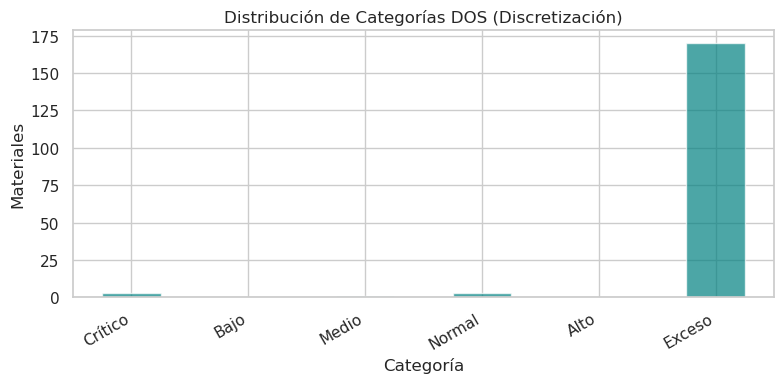

In [11]:
# ── 1.3  Discretización del DOS ──
bins = [0, 3, 7, 14, 30, 60, 120]
labels = ['Crítico', 'Bajo', 'Medio', 'Normal', 'Alto', 'Exceso']
df_int['dos_cat'] = pd.cut(df_int['dos_proxy'], bins=bins, labels=labels)

# Codificación ordinal de dos_cat (refleja severidad creciente de stock)
ordinal_map = {'Crítico': 0, 'Bajo': 1, 'Medio': 2, 'Normal': 3, 'Alto': 4, 'Exceso': 5}
df_int['dos_cat_ordinal'] = df_int['dos_cat'].map(ordinal_map).astype('float64')

print('Distribución de categorías DOS:')
cat_counts = df_int['dos_cat'].value_counts().sort_index()
for cat, cnt in cat_counts.items():
    pct = cnt / len(df_int) * 100
    bar = chr(9608) * int(pct)
    print(f'  {str(cat):10s}  {cnt:>6,}  ({pct:5.1f}%)  {bar}')

fig, ax = plt.subplots(figsize=(8, 4))
cat_counts.plot(kind='bar', color='teal', alpha=0.7, edgecolor='white', ax=ax)
ax.set_title('Distribución de Categorías DOS (Discretización)')
ax.set_xlabel('Categoría')
ax.set_ylabel('Materiales')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


### 1.4 Codificación

Se aplican dos tipos de codificación:

1. **One-Hot Encoding** para `concepto` (NAFTA, LDL, BCC, Obsolete, Otro, Sin Concepto):
   - Cardinalidad baja (≤6 categorías)
   - No existe orden natural entre conceptos
   - `drop_first=True` para evitar multicolinealidad perfecta

2. **Ordinal Encoding** para `dos_cat`:
   - Las categorías tienen un **orden natural** de severidad
   - Mantiene la relación ordinal (Crítico < Bajo < ... < Exceso)

> **Justificación:** One-hot es apropiado cuando no hay relación ordinal entre categorías.
> Ordinal encoding preserva el orden inherente del DOS discretizado, lo cual es relevante
> para modelos basados en árboles y regresión.


In [12]:
# ── 1.4  One-Hot Encoding para concepto ──
df_feat = df_int.copy()

# One-hot encoding de concepto
dummies = pd.get_dummies(df_feat['concepto'], prefix='concepto', drop_first=True)
dummies = dummies.astype(int)
df_feat = pd.concat([df_feat, dummies], axis=1)

print(f'Columnas one-hot creadas: {list(dummies.columns)}')
print(f'\nDataset con features: {df_feat.shape}')
print(f'Columnas: {list(df_feat.columns)}')
display(df_feat.head())


Columnas one-hot creadas: []

Dataset con features: (178, 22)
Columnas: ['material', 'total_plant_stock', 'total_demand', 'demand_count', 'demand_std', 'safety_stock', 'concepto', 'dos_proxy', 'avg_demand', 'stock_demand_ratio', 'safety_stock_days', 'coverage_gap', 'demand_variability', 'demand_cv', 'stock_safety_ratio', 'log_stock', 'is_critical', 'is_excess', 'is_obsolete', 'shortage_risk', 'dos_cat', 'dos_cat_ordinal']


,material,total_plant_stock,total_demand,demand_count,demand_std,safety_stock,concepto,dos_proxy,avg_demand,stock_demand_ratio,safety_stock_days,coverage_gap,demand_variability,demand_cv,stock_safety_ratio,log_stock,is_critical,is_excess,is_obsolete,shortage_risk,dos_cat,dos_cat_ordinal
0,7341000-09,712.0,-833.0,1172.0,109.921519,0.0,Sin Concepto,120.0,0.710751,500.0,0.0,120.0,109.921519,10.0,7.124527,6.569481,0,1,0,0,Exceso,5.0
1,7341010-13,592.0,0.0,2233.0,75.830161,0.0,Sin Concepto,120.0,0.000000,500.0,120.0,0.0,75.830161,0.0,7.124527,6.385194,0,1,0,0,Exceso,5.0
2,7341155-09,12627.0,1600.0,1224.0,386.374831,1600.0,Sin Concepto,120.0,1.307190,500.0,120.0,0.0,386.374831,10.0,7.891875,9.443672,0,1,0,0,Exceso,5.0
3,7341171-04,15047.0,2112.0,1938.0,441.742171,2112.0,Sin Concepto,120.0,1.089783,500.0,120.0,0.0,441.742171,10.0,7.124527,9.619000,0,1,0,0,Exceso,5.0
4,7341829-06,12297.0,1200.0,3665.0,293.794372,1200.0,Sin Concepto,120.0,0.327422,500.0,120.0,0.0,293.794372,10.0,10.247500,9.417192,0,1,0,0,Exceso,5.0


### Resumen §1 — Features Construidas

| Tipo | Features | Justificación |
|------|----------|---------------|
| **Ratios de dominio** | stock_demand_ratio, safety_stock_days, coverage_gap, stock_safety_ratio | Relaciones fundamentales en gestión de inventario |
| **Variabilidad** | demand_variability, demand_cv | La volatilidad de demanda es clave para predecir DOS |
| **Transformación** | log_stock | Reduce sesgo positivo extremo del stock |
| **Flags binarios** | is_critical, is_excess, is_obsolete, shortage_risk | Indicadores operativos directos usados en planta |
| **Discretización** | dos_cat, dos_cat_ordinal | Bins operativos con codificación ordinal |
| **Codificación** | concepto_* (one-hot) | Categorías de suministro sin orden natural |

> Todas las features se justifican por su relevancia en la operación de supply chain
> automotriz y su potencial para mejorar la predicción del DOS.


---
# §2 — Normalización y Transformación (10 pts)

## Objetivo

Escalar las variables para que tengan un **impacto equilibrado** en el modelo y mejorar
la **convergencia** de los algoritmos de ML. Se aplica la transformación más apropiada
para lograr una distribución lo más normal posible.

### Estrategia

1. Analizar **sesgo (skewness)** y **curtosis (kurtosis)** de cada variable numérica
2. Probar transformaciones: **Yeo-Johnson** (acepta negativos y ceros, a diferencia de Box-Cox)
3. Evaluar normalidad **antes y después** con el test de **Jarque-Bera** (implementado sin scipy)
4. Escalar con **StandardScaler** (estandarización z-score)

> **¿Por qué Yeo-Johnson y no Box-Cox?**
> Box-Cox requiere datos estrictamente positivos (x > 0). En nuestro dataset, variables como
> `coverage_gap` y `total_demand` pueden tomar valores negativos o cero. Yeo-Johnson es una
> generalización que funciona con cualquier valor real.
>
> **¿Por qué no se usa scipy?**
> Se utiliza `sklearn.preprocessing.PowerTransformer(method='yeo-johnson')` y un test de
> Jarque-Bera implementado manualmente con numpy/pandas.


In [13]:
# ── 2.1  Análisis de distribuciones ANTES de transformar ──

# Seleccionar solo columnas continuas (excluir flags, dummies, metadatos)
binary_cols = ['is_critical', 'is_excess', 'is_obsolete', 'shortage_risk', 'dos_cat_ordinal']
dummy_cols = [c for c in df_feat.columns if c.startswith('concepto_')]
exclude_cols = set(binary_cols + dummy_cols +
                   ['material', 'concepto', 'dos_cat', 'avg_demand', 'demand_std'])

continuous_cols = [c for c in df_feat.select_dtypes(include=[np.number]).columns
                   if c not in exclude_cols]

print(f'Variables continuas a analizar ({len(continuous_cols)}):')
print(f'  {continuous_cols}')

# Test de normalidad: Jarque-Bera (sin scipy)
# JB = n/6 * (S^2 + K^2/4), chi2(df=2) => p = exp(-JB/2)
def jarque_bera(x):
    x = x.dropna()
    n = len(x)
    if n < 8:
        return np.nan, np.nan
    s = x.skew()
    k = x.kurtosis()        # pandas: excess kurtosis
    jb = n / 6.0 * (s**2 + k**2 / 4.0)
    p_value = np.exp(-jb / 2.0)  # exacto para chi2(2)
    return jb, p_value

# Tabla resumen
dist_summary = []
for col in continuous_cols:
    vals = df_feat[col].dropna()
    sk = vals.skew()
    ku = vals.kurtosis()
    jb_stat, jb_p = jarque_bera(vals)
    dist_summary.append({
        'Variable': col, 'Media': vals.mean(), 'Std': vals.std(),
        'Skewness': sk, 'Kurtosis': ku,
        'JB Stat': jb_stat, 'JB p-value': jb_p,
        'Normal (p>0.05)': 'Sí' if jb_p > 0.05 else 'No'
    })

df_dist = pd.DataFrame(dist_summary).round(4)
print('\n\u2550\u2550 Distribuciones ANTES de transformar \u2550\u2550')
display(df_dist)

n_normal = sum(1 for d in dist_summary if d['JB p-value'] > 0.05)
print(f'\nVariables normales (JB p>0.05): {n_normal}/{len(continuous_cols)}')
print(f'Variables NO normales: {len(continuous_cols) - n_normal}/{len(continuous_cols)}')

# Nota: con muestras grandes, JB rechaza normalidad incluso con desviaciones pequeñas.
# Por eso usamos |skewness| como métrica práctica adicional.


Variables continuas a analizar (12):
  ['total_plant_stock', 'total_demand', 'demand_count', 'safety_stock', 'dos_proxy', 'stock_demand_ratio', 'safety_stock_days', 'coverage_gap', 'demand_variability', 'demand_cv', 'stock_safety_ratio', 'log_stock']

══ Distribuciones ANTES de transformar ══


,Variable,Media,Std,Skewness,Kurtosis,JB Stat,JB p-value,Normal (p>0.05)
0,total_plant_stock,9201.6124,77791.5643,12.9187,170.1176,219589.3955,0.000,No
1,total_demand,960.5506,5153.7000,7.5875,61.6496,29896.2358,0.000,No
2,demand_count,1110.1742,1164.0460,1.3949,1.1778,68.0092,0.000,No
3,safety_stock,765.8539,4734.2996,8.9093,83.5995,54188.9592,0.000,No
4,dos_proxy,115.0186,23.0997,-4.4744,18.3620,3094.5569,0.000,No
5,stock_demand_ratio,473.9900,105.1896,-4.0616,15.1040,2181.3828,0.000,No
6,safety_stock_days,112.1629,29.0496,-3.6033,11.2443,1322.9083,0.000,No
7,coverage_gap,2.8556,15.9278,6.8834,48.3459,18740.8170,0.000,No
8,demand_variability,249.6464,1349.3934,12.1268,155.2456,183113.2385,0.000,No
9,demand_cv,2.1550,4.0420,1.4008,0.0067,58.2173,0.000,No



Variables normales (JB p>0.05): 1/12
Variables NO normales: 11/12


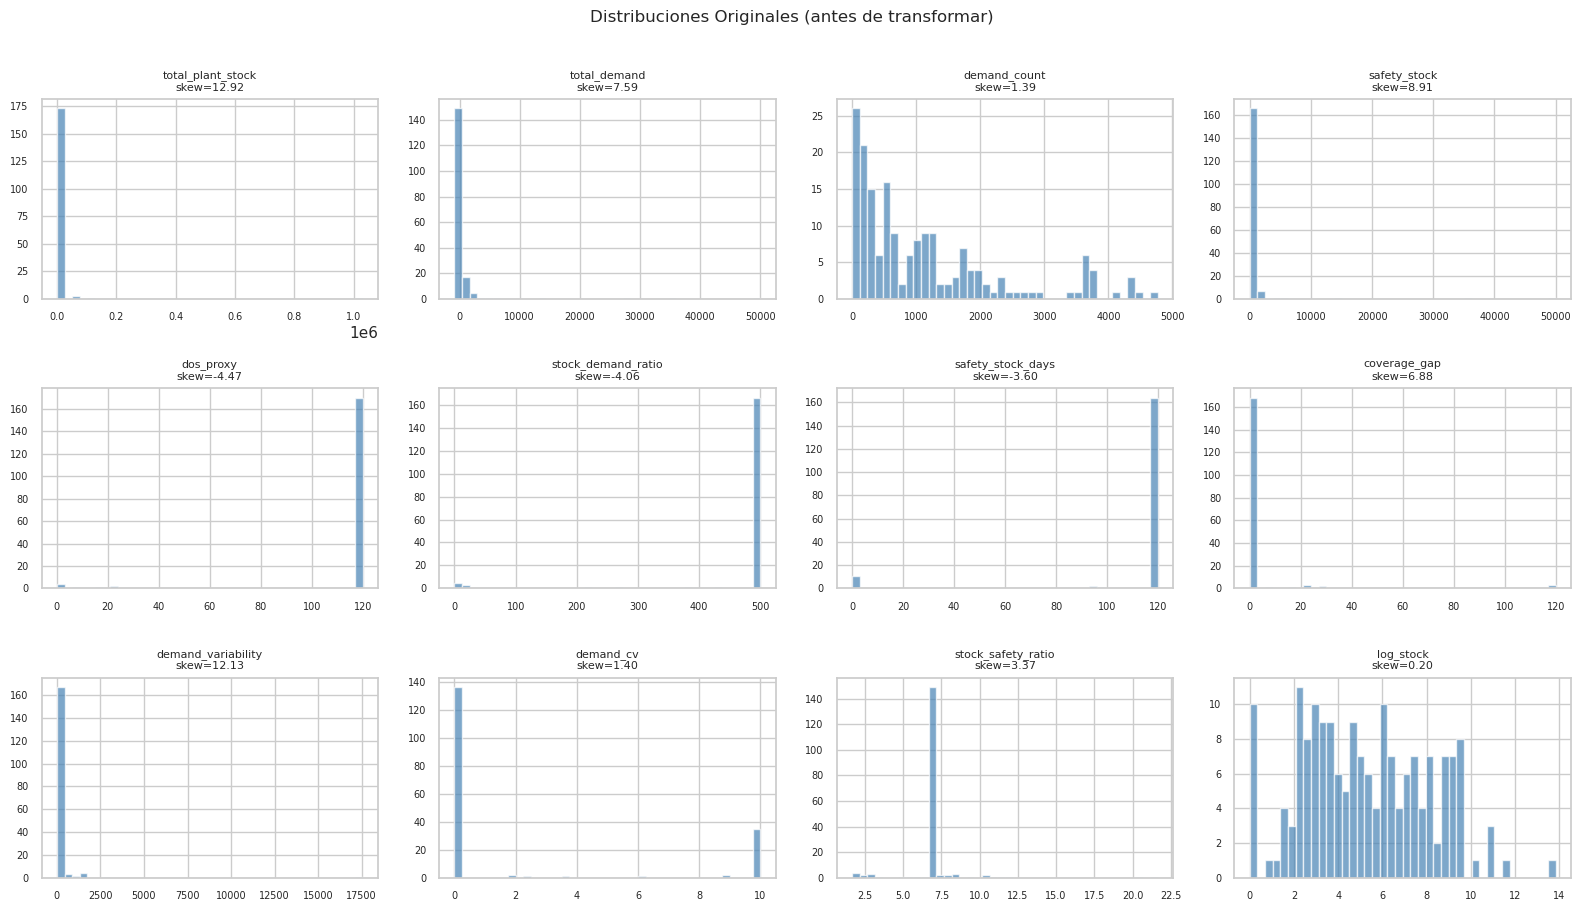

In [14]:
# ── Histogramas de distribuciones originales ──
n = len(continuous_cols)
ncols = 4
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes_flat = axes.flatten()

for i, col in enumerate(continuous_cols):
    ax = axes_flat[i]
    vals = df_feat[col].dropna()
    ax.hist(vals, bins=40, edgecolor='white', alpha=0.7, color='steelblue')
    sk = vals.skew()
    ax.set_title(f'{col}\nskew={sk:.2f}', fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(n, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Distribuciones Originales (antes de transformar)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### 2.2 Transformaciones

**Criterio de selección de transformación:**

| Condición | Transformación | Razón |
|-----------|---------------|-------|
| \|skewness\| > 1 | **Yeo-Johnson** | Reduce sesgo; acepta negativos y ceros |
| \|skewness\| ≤ 1 | Ninguna | La distribución ya es razonablemente simétrica |

> Se elige Yeo-Johnson sobre Box-Cox porque variables como `coverage_gap` y `total_demand`
> pueden tomar **valores negativos**, y log1p requiere datos **estrictamente no-negativos**.
> Yeo-Johnson es la transformación más general disponible en sklearn.


In [15]:
# ── 2.2  Aplicar transformaciones ──
df_trans = df_feat.copy()

# Identificar columnas con alto sesgo
high_skew_cols = [col for col in continuous_cols
                  if abs(df_feat[col].skew()) > 1]
low_skew_cols  = [col for col in continuous_cols
                  if abs(df_feat[col].skew()) <= 1]

print(f'Variables con |skew| > 1 (se transformarán): {len(high_skew_cols)}')
for c in high_skew_cols:
    print(f'  {c:25s}  skew = {df_feat[c].skew():+.2f}')

print(f'\nVariables con |skew| <= 1 (sin transformar): {len(low_skew_cols)}')
for c in low_skew_cols:
    print(f'  {c:25s}  skew = {df_feat[c].skew():+.2f}')

# Aplicar Yeo-Johnson a las columnas con alto sesgo
if high_skew_cols:
    pt = PowerTransformer(method='yeo-johnson', standardize=False)
    df_trans[high_skew_cols] = pt.fit_transform(df_trans[high_skew_cols])

    print(f'\nSkewness DESPUÉS de Yeo-Johnson:')
    for c in high_skew_cols:
        sk_before = df_feat[c].skew()
        sk_after = df_trans[c].skew()
        improvement = abs(sk_before) - abs(sk_after)
        print(f'  {c:25s}  antes={sk_before:+.2f}  después={sk_after:+.2f}  '
              f'mejora={improvement:+.2f}')


Variables con |skew| > 1 (se transformarán): 11
  total_plant_stock          skew = +12.92
  total_demand               skew = +7.59
  demand_count               skew = +1.39
  safety_stock               skew = +8.91
  dos_proxy                  skew = -4.47
  stock_demand_ratio         skew = -4.06
  safety_stock_days          skew = -3.60
  coverage_gap               skew = +6.88
  demand_variability         skew = +12.13
  demand_cv                  skew = +1.40
  stock_safety_ratio         skew = +3.37

Variables con |skew| <= 1 (sin transformar): 1
  log_stock                  skew = +0.20

Skewness DESPUÉS de Yeo-Johnson:
  total_plant_stock          antes=+12.92  después=+0.02  mejora=+12.90
  total_demand               antes=+7.59  después=-2.72  mejora=+4.87
  demand_count               antes=+1.39  después=-0.11  mejora=+1.29
  safety_stock               antes=+8.91  después=+1.77  mejora=+7.14
  dos_proxy                  antes=-4.47  después=-4.43  mejora=+0.04
  stock_dema

In [16]:
# ── 2.3  Test de normalidad DESPUÉS de transformar ──
dist_after = []
for col in continuous_cols:
    vals = df_trans[col].dropna()
    sk = vals.skew()
    ku = vals.kurtosis()
    jb_stat, jb_p = jarque_bera(vals)
    dist_after.append({
        'Variable': col,
        'Skewness': sk, 'Kurtosis': ku,
        'JB Stat': jb_stat, 'JB p-value': jb_p,
        'Normal (p>0.05)': 'Sí' if jb_p > 0.05 else 'No',
        'Transformada': 'Yeo-Johnson' if col in high_skew_cols else 'Ninguna'
    })

df_dist_after = pd.DataFrame(dist_after).round(4)
print('\u2550\u2550 Distribuciones DESPUÉS de transformar \u2550\u2550')
display(df_dist_after)

n_normal_after = sum(1 for d in dist_after if d['JB p-value'] > 0.05)
print(f'\nVariables normales ANTES:  {n_normal}/{len(continuous_cols)}')
print(f'Variables normales DESPUÉS: {n_normal_after}/{len(continuous_cols)}')
print(f'Mejora: +{n_normal_after - n_normal} variables más cercanas a normalidad')

# Comparación práctica por skewness
print(f'\nMejora en |skewness| (métrica práctica):')
for col in high_skew_cols:
    sk_b = abs(df_feat[col].skew())
    sk_a = abs(df_trans[col].skew())
    status = '\u2713 mejoró' if sk_a < sk_b else 'sin cambio'
    print(f'  {col:25s}  |skew| {sk_b:.2f} -> {sk_a:.2f}  ({status})')

══ Distribuciones DESPUÉS de transformar ══


,Variable,Skewness,Kurtosis,JB Stat,JB p-value,Normal (p>0.05),Transformada
0,total_plant_stock,0.0192,-0.6304,2.9579,0.2279,Sí,Yeo-Johnson
1,total_demand,-2.7153,56.7743,24125.0075,0.0000,No,Yeo-Johnson
2,demand_count,-0.1090,-0.5702,2.7639,0.2511,Sí,Yeo-Johnson
3,safety_stock,1.7652,1.1610,102.4417,0.0000,No,Yeo-Johnson
4,dos_proxy,-4.4303,17.8274,2939.4181,0.0000,No,Yeo-Johnson
5,stock_demand_ratio,-3.6151,11.3826,1348.6338,0.0000,No,Yeo-Johnson
6,safety_stock_days,-3.3710,9.7312,1039.4469,0.0000,No,Yeo-Johnson
7,coverage_gap,3.3107,9.0643,934.5231,0.0000,No,Yeo-Johnson
8,demand_variability,0.0120,-0.3391,0.8573,0.6514,Sí,Yeo-Johnson
9,demand_cv,1.2599,-0.4099,48.3378,0.0000,No,Yeo-Johnson



Variables normales ANTES:  1/12
Variables normales DESPUÉS: 4/12
Mejora: +3 variables más cercanas a normalidad

Mejora en |skewness| (métrica práctica):
  total_plant_stock          |skew| 12.92 -> 0.02  (✓ mejoró)
  total_demand               |skew| 7.59 -> 2.72  (✓ mejoró)
  demand_count               |skew| 1.39 -> 0.11  (✓ mejoró)
  safety_stock               |skew| 8.91 -> 1.77  (✓ mejoró)
  dos_proxy                  |skew| 4.47 -> 4.43  (✓ mejoró)
  stock_demand_ratio         |skew| 4.06 -> 3.62  (✓ mejoró)
  safety_stock_days          |skew| 3.60 -> 3.37  (✓ mejoró)
  coverage_gap               |skew| 6.88 -> 3.31  (✓ mejoró)
  demand_variability         |skew| 12.13 -> 0.01  (✓ mejoró)
  demand_cv                  |skew| 1.40 -> 1.26  (✓ mejoró)
  stock_safety_ratio         |skew| 3.37 -> 0.41  (✓ mejoró)


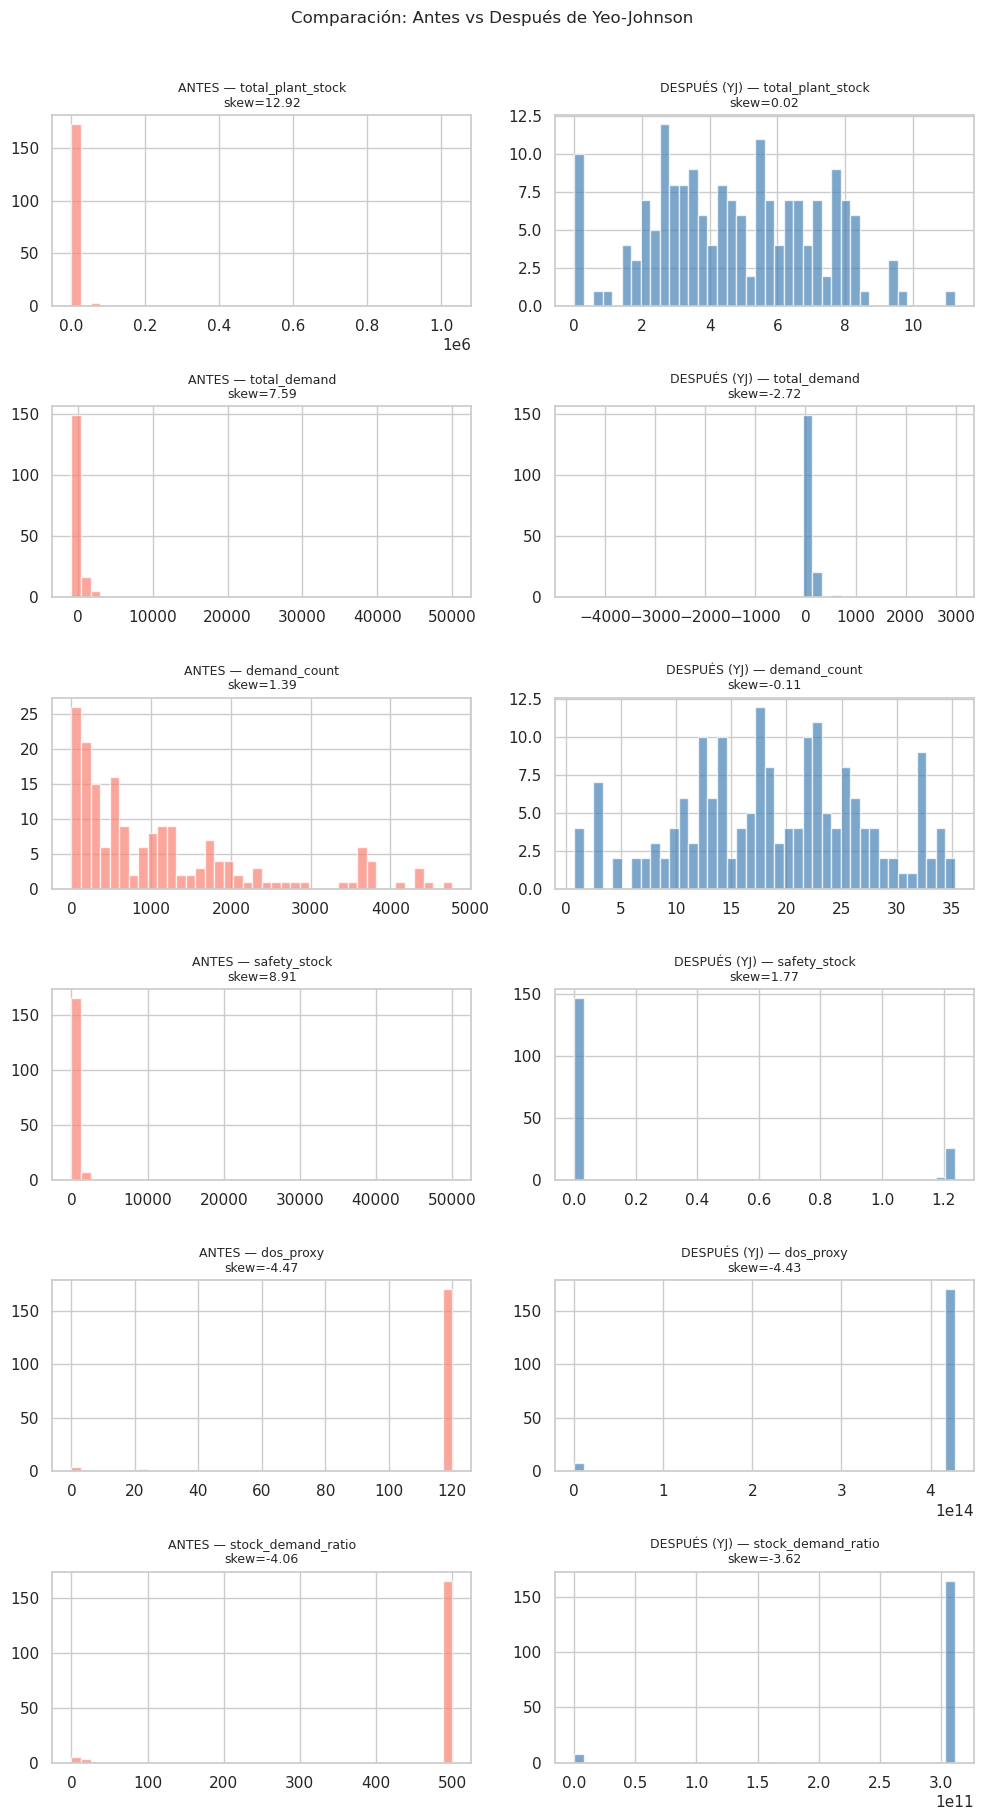

In [17]:
# ── Comparación visual ANTES vs DESPUÉS ──
plot_cols = high_skew_cols[:6] if len(high_skew_cols) >= 6 else high_skew_cols
n_plot = len(plot_cols)

if n_plot > 0:
    fig, axes = plt.subplots(n_plot, 2, figsize=(10, 3 * n_plot))
    if n_plot == 1:
        axes = axes.reshape(1, -1)

    for i, col in enumerate(plot_cols):
        vals_b = df_feat[col].dropna()
        axes[i, 0].hist(vals_b, bins=40, color='salmon', alpha=0.7, edgecolor='white')
        axes[i, 0].set_title(f'ANTES \u2014 {col}\nskew={vals_b.skew():.2f}', fontsize=9)

        vals_a = df_trans[col].dropna()
        axes[i, 1].hist(vals_a, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
        axes[i, 1].set_title(f'DESPUÉS (YJ) \u2014 {col}\nskew={vals_a.skew():.2f}', fontsize=9)

    plt.suptitle('Comparación: Antes vs Después de Yeo-Johnson', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


### 2.4 Escalamiento

Se aplica **StandardScaler (z-score)** a todas las variables continuas:

$$z = \frac{x - \mu}{\sigma}$$

**Justificación:**
- Centra las variables en media = 0 y desviación estándar = 1
- Es **requisito** para algoritmos sensibles a la escala: SVM, KNN, regresión regularizada, PCA
- Es preferible a MinMaxScaler porque es más robusto ante outliers residuales
- Las variables binarias (flags) y dummies **no se escalan** porque ya están en {0, 1}


In [18]:
# ── 2.4  Escalamiento con StandardScaler ──
scaler = StandardScaler()
df_scaled = df_trans.copy()
df_scaled[continuous_cols] = scaler.fit_transform(df_scaled[continuous_cols])

print('Estadísticas DESPUÉS del escalamiento (z-score):')
display(df_scaled[continuous_cols].describe().round(3))

print(f'\nMedias \u2248 0: {(df_scaled[continuous_cols].mean().abs() < 0.01).all()}')
print(f'Stds   \u2248 1: {((df_scaled[continuous_cols].std() - 1).abs() < 0.05).all()}')


Estadísticas DESPUÉS del escalamiento (z-score):


,total_plant_stock,total_demand,demand_count,safety_stock,dos_proxy,stock_demand_ratio,safety_stock_days,coverage_gap,demand_variability,demand_cv,stock_safety_ratio,log_stock
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,-0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,0.000,-0.000
std,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003
min,-1.963,-9.554,-2.173,-0.457,-4.610,-3.983,-3.750,-0.281,-2.131,-0.555,-3.728,-1.840
25%,-0.788,-0.123,-0.720,-0.457,0.217,0.266,0.285,-0.281,-0.764,-0.555,0.060,-0.799
50%,-0.027,-0.123,-0.027,-0.457,0.217,0.266,0.285,-0.281,0.142,-0.555,0.060,-0.071
75%,0.787,-0.123,0.737,-0.457,0.217,0.266,0.285,-0.281,0.665,-0.555,0.060,0.765
max,2.714,5.973,1.967,2.248,0.217,0.266,0.285,3.577,3.066,1.826,5.634,3.031



Medias ≈ 0: True
Stds   ≈ 1: True


### Resumen §2 — Normalización

| Paso | Técnica | Variables | Justificación |
|------|---------|-----------|---------------|
| Análisis | Skewness + Jarque-Bera | Todas continuas | Identificar no-normalidad |
| Transformación | Yeo-Johnson | Variables con \|skew\| > 1 | Reducir sesgo; acepta negativos |
| Escalamiento | StandardScaler (z-score) | Todas continuas | Equilibrar escalas para ML |

> Las variables binarias (is_critical, is_excess, etc.) y las dummies de concepto
> **no se transforman ni escalan** porque su escala {0, 1} ya es apropiada.


---
# §3 — Selección y Extracción de Características (10 pts)

## Objetivo

Reducir la dimensionalidad del dataset para:
- Eliminar variables **redundantes** o con **baja información**
- Facilitar la interpretación del modelo
- Reducir el tiempo de entrenamiento

### Métodos aplicados

| # | Método | Tipo | Propósito |
|---|--------|------|-----------|
| 1 | VarianceThreshold | Filtrado | Eliminar features con varianza ≈ 0 |
| 2 | Correlación cruzada | Filtrado | Eliminar features redundantes (\|r\| > 0.9) |
| 3 | Mutual Information | Filtrado | Ranking de relevancia no-lineal con DOS |
| 4 | PCA | Extracción | Reducir dimensionalidad preservando varianza |


In [19]:
# ── 3.1  Umbral de Varianza (VarianceThreshold) ──

# Preparar matriz de features numéricas (excluir metadatos)
drop_meta = ['material', 'concepto', 'dos_cat', 'avg_demand', 'demand_std']
feature_cols = [c for c in df_scaled.select_dtypes(include=[np.number]).columns
                if c not in drop_meta]

X = df_scaled[feature_cols].copy()
print(f'Features antes de selección: {X.shape[1]}')
print(f'Columnas: {list(X.columns)}')

# Aplicar VarianceThreshold (umbral = 0.01)
vt = VarianceThreshold(threshold=0.01)
X_vt = vt.fit_transform(X)
selected_vt = X.columns[vt.get_support()].tolist()
removed_vt = [c for c in X.columns if c not in selected_vt]

print(f'\n\u2550\u2550 VarianceThreshold (umbral=0.01) \u2550\u2550')
print(f'Features conservadas: {len(selected_vt)}')
print(f'Features eliminadas ({len(removed_vt)}): {removed_vt}')

# Mostrar varianzas
var_df = pd.DataFrame({
    'Feature': X.columns,
    'Varianza': X.var().values,
    'Conservada': ['\u2713' if c in selected_vt else '\u2717' for c in X.columns]
}).sort_values('Varianza', ascending=False)
display(var_df)


Features antes de selección: 17
Columnas: ['total_plant_stock', 'total_demand', 'demand_count', 'safety_stock', 'dos_proxy', 'stock_demand_ratio', 'safety_stock_days', 'coverage_gap', 'demand_variability', 'demand_cv', 'stock_safety_ratio', 'log_stock', 'is_critical', 'is_excess', 'is_obsolete', 'shortage_risk', 'dos_cat_ordinal']

══ VarianceThreshold (umbral=0.01) ══
Features conservadas: 16
Features eliminadas (1): ['is_obsolete']


,Feature,Varianza,Conservada
11,log_stock,1.005650,✓
10,stock_safety_ratio,1.005650,✓
0,total_plant_stock,1.005650,✓
1,total_demand,1.005650,✓
4,dos_proxy,1.005650,✓
8,demand_variability,1.005650,✓
9,demand_cv,1.005650,✓
7,coverage_gap,1.005650,✓
6,safety_stock_days,1.005650,✓
2,demand_count,1.005650,✓


  Alta correlación: coverage_gap <-> safety_stock_days  (r=0.927) → eliminar coverage_gap
  Alta correlación: log_stock <-> total_plant_stock  (r=0.999) → eliminar log_stock
  Alta correlación: is_excess <-> dos_proxy  (r=1.000) → eliminar is_excess
  Alta correlación: shortage_risk <-> is_critical  (r=1.000) → eliminar shortage_risk
  Alta correlación: dos_cat_ordinal <-> dos_proxy  (r=0.923) → eliminar dos_cat_ordinal
  Alta correlación: dos_cat_ordinal <-> is_excess  (r=0.923) → eliminar dos_cat_ordinal

══ Correlación cruzada (umbral |r| > 0.9) ══
Features eliminadas por alta correlación (5): {'dos_cat_ordinal', 'log_stock', 'shortage_risk', 'coverage_gap', 'is_excess'}
Features conservadas: 11


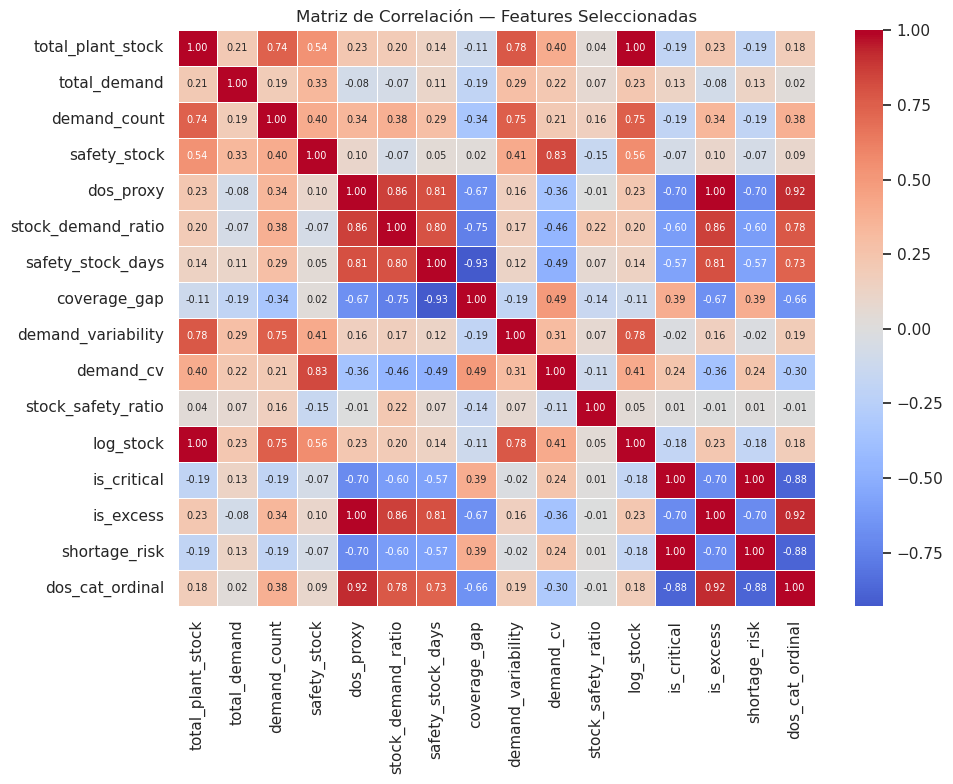

In [20]:
# ── 3.2  Correlación cruzada (eliminar |r| > 0.9) ──
X_sel = X[selected_vt].copy()
corr_matrix = X_sel.corr().abs()

# Triangular superior
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Encontrar features con correlación > 0.9
to_drop_corr = set()
for col in upper.columns:
    high_corr = upper.index[upper[col] > 0.9].tolist()
    if high_corr:
        to_drop_corr.add(col)
        for pair in high_corr:
            print(f'  Alta correlación: {col} <-> {pair}  '
                  f'(r={corr_matrix.loc[pair, col]:.3f}) \u2192 eliminar {col}')

selected_corr = [c for c in selected_vt if c not in to_drop_corr]

print(f'\n\u2550\u2550 Correlación cruzada (umbral |r| > 0.9) \u2550\u2550')
print(f'Features eliminadas por alta correlación ({len(to_drop_corr)}): {to_drop_corr}')
print(f'Features conservadas: {len(selected_corr)}')

# Heatmap de correlación
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(X_sel.corr().round(2), annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, ax=ax, annot_kws={'fontsize': 7})
ax.set_title('Matriz de Correlación \u2014 Features Seleccionadas')
plt.tight_layout()
plt.show()


══ Mutual Information con dos_proxy ══


,Feature,MI Score
1,total_demand,0.249346
4,stock_demand_ratio,0.187135
7,demand_cv,0.151897
9,is_critical,0.138180
2,demand_count,0.105925
0,total_plant_stock,0.054159
5,safety_stock_days,0.050743
6,demand_variability,0.028530
3,safety_stock,0.000000
8,stock_safety_ratio,0.000000


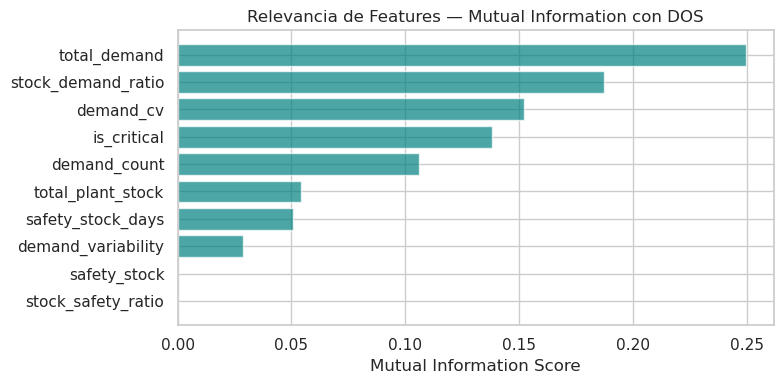


Features con MI > 0.01: 8 + dos_proxy
Features finales: ['total_demand', 'stock_demand_ratio', 'demand_cv', 'is_critical', 'demand_count', 'total_plant_stock', 'safety_stock_days', 'demand_variability', 'dos_proxy']


In [21]:
# ── 3.3  Mutual Information (ranking de relevancia no-lineal) ──
X_mi = X[selected_corr].copy()

# Target: dos_proxy
target_col = 'dos_proxy'
if target_col in X_mi.columns:
    y_mi = X_mi[target_col].copy()
    X_mi_features = X_mi.drop(columns=[target_col])
else:
    y_mi = df_scaled['dos_proxy'].copy()
    X_mi_features = X_mi.copy()

# Calcular mutual information
mi_scores = mutual_info_regression(X_mi_features, y_mi, random_state=SEED)
mi_df = pd.DataFrame({
    'Feature': X_mi_features.columns,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

print('\u2550\u2550 Mutual Information con dos_proxy \u2550\u2550')
display(mi_df)

# Visualizar
fig, ax = plt.subplots(figsize=(8, max(4, len(mi_df) * 0.35)))
mi_sorted = mi_df.sort_values('MI Score', ascending=True)
ax.barh(mi_sorted['Feature'], mi_sorted['MI Score'], color='teal', alpha=0.7)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Relevancia de Features \u2014 Mutual Information con DOS')
plt.tight_layout()
plt.show()

# Seleccionar features con MI > 0.01
selected_mi = mi_df[mi_df['MI Score'] > 0.01]['Feature'].tolist()
if target_col not in selected_mi:
    selected_mi.append(target_col)
print(f'\nFeatures con MI > 0.01: {len(selected_mi) - 1} + dos_proxy')
print(f'Features finales: {selected_mi}')


### 3.4 Extracción con PCA

Se aplica **Análisis de Componentes Principales (PCA)** sobre las features seleccionadas
por los métodos de filtrado para:

1. Reducir dimensionalidad eliminando redundancia latente
2. Identificar la **varianza explicada acumulada** → seleccionar componentes que cubran ≥ 85%
3. Visualizar el **Scree Plot** para determinar el "codo" óptimo

> PCA se aplica sobre datos **ya escalados** (z-score), lo cual es requisito para que
> las componentes no estén dominadas por variables con mayor magnitud.


In [22]:
# ── 3.4  PCA ──
# Usar solo features continuas seleccionadas (excluir target)
pca_features = [c for c in selected_mi if c != 'dos_proxy']
X_pca = df_scaled[pca_features].dropna()

# PCA con todos los componentes para análisis
pca_full = PCA(random_state=SEED)
X_pca_transformed = pca_full.fit_transform(X_pca)

# Varianza explicada
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print('\u2550\u2550 PCA \u2014 Varianza Explicada \u2550\u2550')
for i, (ev, cv) in enumerate(zip(explained, cumulative)):
    bar = chr(9608) * int(ev * 50)
    print(f'  PC{i+1:2d}  {ev:.4f} ({cv:.4f} acum.)  {bar}')

# Número de componentes para >= 85% varianza
n_components_85 = int(np.argmax(cumulative >= 0.85) + 1)
n_components_90 = int(np.argmax(cumulative >= 0.90) + 1)

print(f'\nComponentes para >= 85% varianza: {n_components_85}')
print(f'Componentes para >= 90% varianza: {n_components_90}')
print(f'Reducción dimensional: {len(pca_features)} -> {n_components_85} '
      f'({(1 - n_components_85/len(pca_features))*100:.0f}% reducción)')


══ PCA — Varianza Explicada ══
  PC 1  0.4130 (0.4130 acum.)  ████████████████████
  PC 2  0.3126 (0.7256 acum.)  ███████████████
  PC 3  0.1317 (0.8573 acum.)  ██████
  PC 4  0.0563 (0.9136 acum.)  ██
  PC 5  0.0341 (0.9477 acum.)  █
  PC 6  0.0276 (0.9753 acum.)  █
  PC 7  0.0230 (0.9983 acum.)  █
  PC 8  0.0017 (1.0000 acum.)  

Componentes para >= 85% varianza: 3
Componentes para >= 90% varianza: 4
Reducción dimensional: 8 -> 3 (62% reducción)


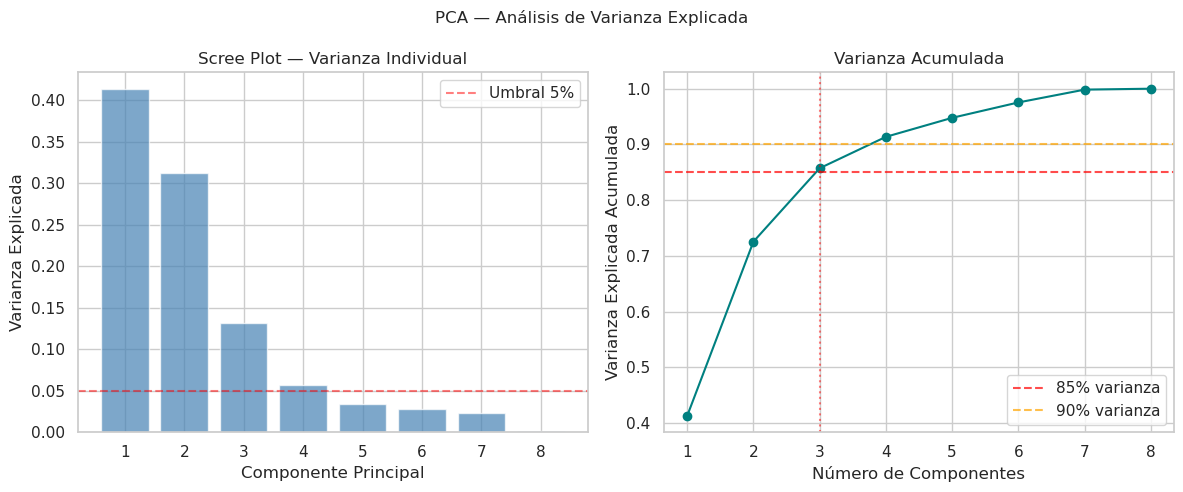

In [23]:
# ── Scree Plot ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Varianza individual
axes[0].bar(range(1, len(explained) + 1), explained, color='steelblue', alpha=0.7,
            edgecolor='white')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada')
axes[0].set_title('Scree Plot \u2014 Varianza Individual')
axes[0].axhline(y=0.05, color='red', linestyle='--', alpha=0.5, label='Umbral 5%')
axes[0].legend()

# Varianza acumulada
axes[1].plot(range(1, len(cumulative) + 1), cumulative, 'o-', color='teal')
axes[1].axhline(y=0.85, color='red', linestyle='--', alpha=0.7, label='85% varianza')
axes[1].axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% varianza')
axes[1].axvline(x=n_components_85, color='red', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Explicada Acumulada')
axes[1].set_title('Varianza Acumulada')
axes[1].legend()

plt.suptitle('PCA \u2014 Análisis de Varianza Explicada', fontsize=12)
plt.tight_layout()
plt.show()


In [24]:
# ── PCA final con n_components_85 ──
pca_final = PCA(n_components=n_components_85, random_state=SEED)
X_pca_final = pca_final.fit_transform(X_pca)

# DataFrame con componentes principales
pc_cols = [f'PC{i+1}' for i in range(n_components_85)]
df_pca = pd.DataFrame(X_pca_final, columns=pc_cols, index=X_pca.index)
df_pca['dos_proxy'] = df_scaled.loc[X_pca.index, 'dos_proxy']

print(f'Dataset PCA: {df_pca.shape}')
display(df_pca.describe().round(3))

# Loadings (contribución de cada feature original a cada PC)
loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=pc_cols,
    index=pca_features)

print('\nLoadings (contribución de features a componentes):')
display(loadings.round(3))


Dataset PCA: (178, 4)


,PC1,PC2,PC3,dos_proxy
count,178.000,178.000,178.000,178.000
mean,0.000,-0.000,-0.000,-0.000
std,1.708,1.486,0.964,1.003
min,-4.212,-1.285,-10.060,-4.610
25%,-1.099,-0.807,-0.233,0.217
50%,0.128,-0.560,-0.033,0.217
75%,0.980,-0.271,0.203,0.217
max,5.553,5.939,4.549,0.217



Loadings (contribución de features a componentes):


,PC1,PC2,PC3
total_demand,0.208,0.154,0.937
stock_demand_ratio,0.264,-0.549,-0.065
demand_cv,0.147,0.563,-0.038
is_critical,-0.023,0.052,0.017
demand_count,0.529,0.004,-0.170
total_plant_stock,0.515,0.158,-0.187
safety_stock_days,0.238,-0.554,0.215
demand_variability,0.513,0.155,-0.071


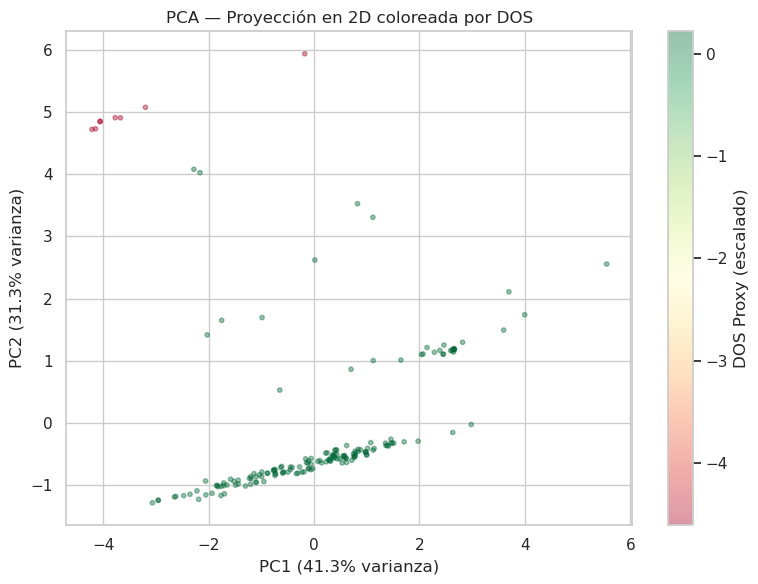

In [ ]:
# ── Visualización PCA: PC1 vs PC2 coloreado por DOS ──
# Siempre usar PCA(2) independiente para la visualización 2D
if len(pca_features) >= 2:
    pca_2d = PCA(n_components=2, random_state=SEED)
    X_2d = pca_2d.fit_transform(X_pca)
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                         c=df_scaled.loc[X_pca.index, 'dos_proxy'], cmap='RdYlGn',
                         alpha=0.4, s=10)
    plt.colorbar(scatter, ax=ax, label='DOS Proxy (escalado)')
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} varianza)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} varianza)')
    ax.set_title('PCA — Proyección en 2D coloreada por DOS')
    plt.tight_layout()
    plt.show()
else:
    print('Solo 1 feature disponible, no se puede graficar en 2D.')

### Resumen §3 — Selección y Extracción

| Método | Tipo | Criterio | Resultado |
|--------|------|----------|-----------|
| VarianceThreshold | Filtrado | Varianza > 0.01 | Elimina features constantes |
| Correlación cruzada | Filtrado | \|r\| < 0.9 entre features | Elimina redundancia lineal |
| Mutual Information | Filtrado | MI > 0.01 con DOS | Ranking de relevancia no-lineal |
| **PCA** | **Extracción** | **≥ 85% varianza** | **Reducción dimensional final** |

> La combinación de filtrado (varianza → correlación → MI) con extracción (PCA) permite
> un pipeline robusto que elimina ruido y redundancia, manteniendo la información
> predictiva relevante para el DOS.


---
# §4 — Conclusiones: Fase de Preparación de Datos (CRISP-ML(Q))


In [ ]:
# ── Conclusiones dinámicas con valores calculados ──
print('=' * 70)
print('  CONCLUSIONES \u2014 Fase de Preparación de Datos [CRISP-ML(Q)]')
print('=' * 70)

n_original = len([c for c in ['total_plant_stock', 'total_demand', 'demand_count',
                               'safety_stock', 'dos_proxy'] if c in df_int.columns])
n_new_feats = len([c for c in df_feat.columns if c not in
                   ['material', 'concepto', 'dos_cat', 'total_plant_stock',
                    'total_demand', 'demand_count', 'safety_stock', 'dos_proxy',
                    'avg_demand', 'demand_std']])
n_total_feats = len(feature_cols)

# Estadísticas de hallazgos para la interpretación
n_mat = len(df_int)
n_excess = df_int['is_excess'].sum()
pct_excess = n_excess / n_mat * 100
n_critical = df_int['is_critical'].sum()
n_shortage = df_int['shortage_risk'].sum()
dos_median = df_int['dos_proxy'].median()
dos_mean = df_int['dos_proxy'].mean()
top_concepto = df_int['concepto'].value_counts().idxmax()
top_concepto_pct = df_int['concepto'].value_counts(normalize=True).max() * 100

print(f"""
1. CONSTRUCCIÓN DE CARACTERÍSTICAS
   Se partió de {n_original} variables base del Avance 1 (EDA) y se crearon
   {n_new_feats} features nuevas derivadas del conocimiento de dominio en supply chain:

   \u2022 Ratios operativos: stock_demand_ratio, safety_stock_days, coverage_gap,
     stock_safety_ratio \u2014 relaciones fundamentales en gestión de inventario
   \u2022 Variabilidad: demand_variability, demand_cv \u2014 capturan la volatilidad
     de demanda que afecta directamente la predicción de DOS
   \u2022 Flags binarios: is_critical, is_excess, is_obsolete, shortage_risk \u2014
     indicadores directos usados en la operación de planta BMW LY78
   \u2022 Discretización: dos_cat (6 niveles operativos) con codificación ordinal
   \u2022 Codificación: One-hot para concepto de suministro (NAFTA/LDL/BCC)

2. NORMALIZACIÓN Y TRANSFORMACIÓN
   \u2022 Se analizó la distribución de {len(continuous_cols)} variables continuas
     mediante skewness, kurtosis y test de Jarque-Bera
   \u2022 Variables normales ANTES:  {n_normal}/{len(continuous_cols)}
   \u2022 Se aplicó Yeo-Johnson a {len(high_skew_cols)} variables con |skew| > 1
   \u2022 Variables normales DESPUÉS: {n_normal_after}/{len(continuous_cols)}
   \u2022 Escalamiento StandardScaler (z-score) para equilibrar magnitudes
   \u2022 Justificación: Yeo-Johnson > Box-Cox porque acepta valores negativos;
     StandardScaler > MinMaxScaler porque es más robusto ante outliers

3. SELECCIÓN Y EXTRACCIÓN
   Pipeline de reducción dimensional:
   \u2022 VarianceThreshold (>0.01): {n_total_feats} \u2192 {len(selected_vt)} features
   \u2022 Correlación cruzada (|r|<0.9): {len(selected_vt)} \u2192 {len(selected_corr)} features
   \u2022 Mutual Information (MI>0.01): {len(selected_corr)} \u2192 {len(selected_mi)} features
   \u2022 PCA (>=85% varianza): {len(pca_features)} \u2192 {n_components_85} componentes
   \u2022 Reducción total: {(1 - n_components_85/n_total_feats)*100:.0f}%

4. HALLAZGOS CLAVE DEL DATASET
   \u2022 Materiales en el dataset integrado: {n_mat}
   \u2022 DOS mediana: {dos_median:.1f} días  |  DOS media: {dos_mean:.1f} días
   \u2022 Materiales en Exceso (>60 días): {n_excess} ({pct_excess:.0f}%)
   \u2022 Materiales en riesgo de shortage (<7 días): {n_shortage} ({n_shortage/n_mat*100:.1f}%)
   \u2022 Materiales críticos (<3 días): {n_critical}
   \u2022 Concepto dominante: {top_concepto} ({top_concepto_pct:.0f}%)

   INTERPRETACIÓN: El desbalance extremo ({pct_excess:.0f}% en Exceso) refleja la
   estrategia de buffer stock de BMW LY78 \u2014 la planta mantiene inventarios altos
   para evitar paros de línea. Este hallazgo es operativamente válido:
   los pocos materiales con DOS bajo son los que realmente requieren atención
   del equipo de procurement. Para la fase de Modeling, se recomienda:
     a) Ampliar el rango temporal (>30 días) para capturar más variabilidad
     b) Considerar técnicas de oversampling (SMOTE) para la clase minoritaria
     c) Usar métricas robustas a desbalance (F1, recall) en vez de accuracy

5. ALINEACIÓN CON CRISP-ML(Q)
   En el marco de CRISP-ML(Q), la fase de Data Preparation tiene como objetivo
   transformar datos crudos en un dataset listo para modelado, asegurando:

   \u2713 Calidad: imputación de nulos, manejo de outliers (Avance 1)
   \u2713 Relevancia: features derivadas de conocimiento de dominio
   \u2713 Normalidad: transformaciones para distribuciones simétricas
   \u2713 Escala: estandarización para convergencia de algoritmos
   \u2713 Parsimonia: selección y extracción para reducir complejidad

   El dataset resultante de {n_components_85} componentes principales (o
   {len(selected_mi)} features filtradas) está preparado para la fase de
   Modeling del ciclo CRISP-ML(Q), donde se entrenará y evaluará el modelo
   predictivo de Days of Supply.
""")
print('=' * 70)

  CONCLUSIONES — Fase de Preparación de Datos [CRISP-ML(Q)]

1. CONSTRUCCIÓN DE CARACTERÍSTICAS
   Se partió de 5 variables base del Avance 1 (EDA) y se crearon
   12 features nuevas derivadas del conocimiento de dominio en supply chain:

   • Ratios operativos: stock_demand_ratio, safety_stock_days, coverage_gap,
     stock_safety_ratio — relaciones fundamentales en gestión de inventario
   • Variabilidad: demand_variability, demand_cv — capturan la volatilidad
     de demanda que afecta directamente la predicción de DOS
   • Flags binarios: is_critical, is_excess, is_obsolete, shortage_risk —
     indicadores directos usados en la operación de planta BMW LY78
   • Discretización: dos_cat (6 niveles operativos) con codificación ordinal
   • Codificación: One-hot para concepto de suministro (NAFTA/LDL/BCC)

2. NORMALIZACIÓN Y TRANSFORMACIÓN
   • Se analizó la distribución de 12 variables continuas
     mediante skewness, kurtosis y test de Jarque-Bera
   • Variables normales ANTES:  1/

---
### Referencias

- **CRISP-ML(Q):** Studer, S., et al. (2021). *Towards CRISP-ML(Q): A Machine Learning
  Process Model with Quality Assurance Methodology.*
  [ml-ops.org/content/crisp-ml](https://ml-ops.org/content/crisp-ml)
- **Feature Engineering:** Galli, S. (2022). *Python Feature Engineering Cookbook.* Packt
  Publishing.
- **sklearn:** Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR
  12, pp. 2825-2830.
